# Stage 4: Validation and Fitting

## Goal

This notebook implements and validates the model-fitting procedure using **real empirical MEG data**.

### Phase 1 — Synthetic validation (sanity check)
1. Simulate network activity with known ground-truth values of *K* and *λ*
2. Add measurement noise
3. Compute a synthetic empirical PLI matrix
4. Fit *K* and *λ* by maximising Pearson correlation
5. Confirm that recovered parameters match ground truth

### Phase 2 — Fitting to real empirical data
- **Control group** (`control_PLI_raw.csv`): group-averaged PLI from healthy participants (78 × 78 regions)
- **Glioma group** (`glioma_PLI_raw.csv`): group-averaged PLI from glioma patients (78 × 78 regions)

> **Why Pearson correlation?**  
> We care about the *spatial pattern* of functional connectivity, not the absolute PLI values.


In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import pearsonr

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE_DIR = PROJECT_ROOT / "figures" / "hopf model" / "validation and fitting"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {path}")


## Hopf Network Model

We use a network of **coupled Hopf oscillators**, where:
- Each node represents a brain region (78 regions from a parcellation atlas)
- Nodes are coupled through a structural connectivity (SC) matrix *W*, derived from diffusion MRI tractography
- Each node follows a normal form Hopf bifurcation:

$$\dot{x}_i = x_i(\lambda - r_i^2) - \omega_i y_i + K \tanh\left(C \sum_j W_{ij} x_j\right)$$
$$\dot{y}_i = y_i(\lambda - r_i^2) + \omega_i x_i$$

where:
- $\lambda$ controls **local excitability** (negative → damped oscillation; positive → limit cycle)
- $K$ is the **global coupling strength**
- $\omega_i = 2\pi f_i$ is the natural frequency of node $i$ (set to the empirical peak frequency)
- $C$ is a saturation constant (fixed at 1)

The two free parameters we fit are **$K$** and **$\lambda$**.


In [ ]:
# -----------------------------
# Hopf model
# -----------------------------

def hopf_rhs(_t, state, _N, W, K, lam, C, omega):
    """
    Coupled Hopf oscillator ODE.
    State vector is [x1, y1, x2, y2, ..., xN, yN].
    """
    x = state[0::2]
    y = state[1::2]

    r2 = x**2 + y**2

    dx = x * (lam - r2) - omega * y + K * np.tanh(C * (W @ x))
    dy = y * (lam - r2) + omega * x

    out = np.empty_like(state)
    out[0::2] = dx
    out[1::2] = dy
    return out


def random_initial_conditions(N, rng=None, scale=0.1):
    """
    Random complex initial conditions for N nodes.
    """
    rng = np.random.default_rng(rng)
    return scale * (rng.standard_normal(N) + 1j * rng.standard_normal(N))


def simulate_hopf(N, W, K, lam, C, omega, z0=None,
                  t_total=20.0, t_discard=5.0, fs=250):
    """
    Simulate coupled Hopf oscillators.

    Returns
    -------
    t : array, shape (T,)
    x : array, shape (N, T)
    y : array, shape (N, T)
    """
    if z0 is None:
        z0 = random_initial_conditions(N, rng=42)
    elif np.isscalar(z0):
        z0 = np.full(N, z0, dtype=complex)

    state0 = np.empty(2 * N)
    state0[0::2] = np.real(z0)
    state0[1::2] = np.imag(z0)

    t_eval = np.arange(0.0, t_total, 1.0 / fs)

    sol = solve_ivp(
        hopf_rhs,
        t_span=(0.0, t_total),
        y0=state0,
        t_eval=t_eval,
        args=(N, W, K, lam, C, omega),
        rtol=1e-6,
        atol=1e-8,
    )

    state = sol.y
    x = state[0::2]
    y = state[1::2]
    t = sol.t

    keep = t >= t_discard
    return t[keep], x[:, keep], y[:, keep]

## Signal Processing and PLI

After simulation, node signals are:
1. **Band-pass filtered** (8–12 Hz, alpha band) using a 4th-order Butterworth filter
2. **Hilbert-transformed** to extract instantaneous phase
3. **PLI** (Phase Lag Index) is computed between all pairs of nodes:

$$\text{PLI}_{ij} = \left|\langle \text{sign}(\sin(\Delta\phi_{ij}(t))) \rangle_t\right|$$

PLI measures the asymmetry of the phase difference distribution — it is robust to volume conduction artefacts because it ignores zero-lag phase coupling.


In [ ]:
# -----------------------------
# Signal processing and PLI
# -----------------------------

def bandpass_filter(signals, fs, f_lo=8.0, f_hi=12.0, order=4):
    """
    Band-pass filter node signals.

    Parameters
    ----------
    signals : array, shape (N, T)
    fs : float
        Sampling frequency
    """
    nyq = 0.5 * fs
    b, a = butter(order, [f_lo / nyq, f_hi / nyq], btype="band")
    return filtfilt(b, a, signals, axis=1)


def compute_pli(signals):
    """
    Compute Phase Lag Index (PLI) matrix from node signals.

    Parameters
    ----------
    signals : array, shape (N, T)

    Returns
    -------
    pli : array, shape (N, N)
    """
    phases = np.angle(hilbert(signals, axis=1))
    N = signals.shape[0]
    pli = np.zeros((N, N))

    for i in range(N):
        for j in range(i + 1, N):
            dphi = phases[i] - phases[j]
            pli_ij = np.abs(np.mean(np.sign(np.sin(dphi))))
            pli[i, j] = pli_ij
            pli[j, i] = pli_ij

    return pli


def upper_triangle_values(mat):
    """
    Return the upper-triangle values of a symmetric matrix, excluding diagonal.
    """
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

## Phase 1 — Synthetic Validation

### Step 1: Small synthetic test network

We first build a small 6-node synthetic network with a known connectivity structure to test the simulation pipeline before scaling to 78 regions.


Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\synthetic_structural_connectivity.png


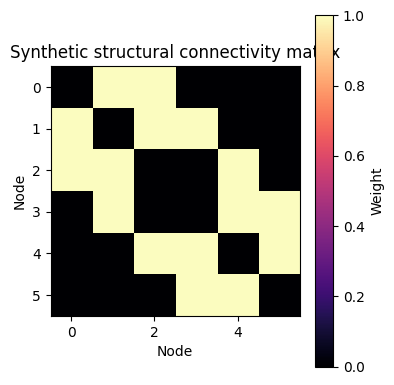

In [ ]:
# -----------------------------
# Small synthetic test network
# -----------------------------

N = 6

W = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 1],
    [0, 0, 1, 1, 0, 1],
    [0, 0, 0, 1, 1, 0],
], dtype=float)

W = W / W.max()

omega_hz = 10.0
omega = 2 * np.pi * omega_hz * np.ones(N)

fs = 250
t_total = 20.0
t_discard = 5.0
C = 1.0

z0 = random_initial_conditions(N, rng=42)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap="magma")
ax.set_title("Synthetic structural connectivity matrix")
ax.set_xlabel("Node")
ax.set_ylabel("Node")
plt.colorbar(im, ax=ax, label="Weight")
fig.tight_layout()
save_figure(fig, "synthetic_structural_connectivity.png")

### Step 2: Generate synthetic empirical PLI

We simulate the model with **known ground-truth parameters** ($K_{\text{true}}$, $\lambda_{\text{true}}$), optionally add noise, and compute the resulting PLI matrix. This will serve as our "empirical" target for the fitting step.


In [ ]:
# -----------------------------
# Generate synthetic empirical PLI
# -----------------------------

def generate_synthetic_empirical_pli(N, W, K_true, lam_true, C, omega, z0,
                                     t_total=20.0, t_discard=5.0, fs=250,
                                     noise_std=0.05, f_lo=8.0, f_hi=12.0):
    """
    Generate synthetic empirical PLI by:
    1. simulating the model with known parameters
    2. adding measurement noise
    3. filtering the noisy signals
    4. computing the PLI matrix
    """
    t, x, y = simulate_hopf(
        N=N, W=W, K=K_true, lam=lam_true, C=C,
        omega=omega, z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )

    noisy_x = x + noise_std * np.random.randn(*x.shape)
    filtered_x = bandpass_filter(noisy_x, fs=fs, f_lo=f_lo, f_hi=f_hi)
    pli_emp = compute_pli(filtered_x)

    return t, noisy_x, filtered_x, pli_emp

### Step 3: Run the synthetic simulation

We set the ground-truth parameters and generate the synthetic empirical PLI. The resulting signal and PLI matrix are visualised below.


Ground-truth parameters: K = 0.800, lambda = 1.000
Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\synthetic_empirical_signal_and_pli.png


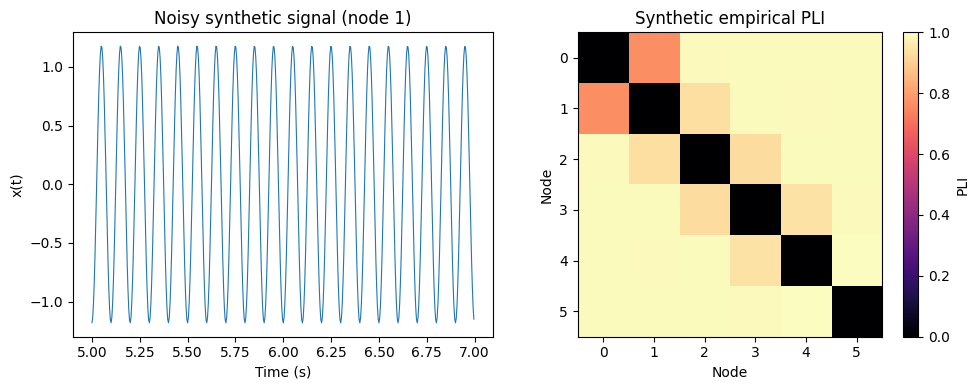

In [ ]:
K_true = 0.8
lam_true = 1.0

t_emp, x_emp_noisy, x_emp_filt, pli_emp = generate_synthetic_empirical_pli(
    N=N, W=W, K_true=K_true, lam_true=lam_true, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
    noise_std=0,
)

print(f"Ground-truth parameters: K = {K_true:.3f}, lambda = {lam_true:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_emp[:500], x_emp_noisy[0, :500], lw=0.8)
axes[0].set_title("Noisy synthetic signal (node 1)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")

im = axes[1].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[1].set_title("Synthetic empirical PLI")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

plt.colorbar(im, ax=axes[1], label="PLI")
fig.tight_layout()
save_figure(fig, "synthetic_empirical_signal_and_pli.png")

### Step 4: Grid search to fit *K* and *λ*

We perform an exhaustive grid search over a range of *K* and *λ* values. For each parameter pair:
1. Simulate the network
2. Filter and compute PLI
3. Measure Pearson correlation with the synthetic empirical PLI

The parameter pair achieving the highest correlation is taken as the fitted estimate.


In [ ]:
# -----------------------------
# Fit K and lambda by grid search
# -----------------------------

def fit_k_lambda_grid(N, W, pli_emp, K_values, lam_values, C, omega, z0,
                      t_total=20.0, t_discard=5.0, fs=250,
                      f_lo=8.0, f_hi=12.0):
    """
    Grid search over K and lambda.
    For each parameter pair:
    1. simulate the network
    2. filter the simulated signals
    3. compute simulated PLI
    4. compare simulated PLI to synthetic empirical PLI with Pearson correlation

    Returns
    -------
    corr_map : array, shape (len(K_values), len(lam_values))
    best_corr : float
    best_params : tuple (K_best, lam_best)
    best_pli : array, shape (N, N)
    """
    emp_vals = upper_triangle_values(pli_emp)

    corr_map = np.zeros((len(K_values), len(lam_values)))
    best_corr = -np.inf
    best_params = None
    best_pli = None

    for i, K in enumerate(K_values):
        for j, lam in enumerate(lam_values):
            t, x, y = simulate_hopf(
                N=N, W=W, K=K, lam=lam, C=C,
                omega=omega, z0=z0,
                t_total=t_total, t_discard=t_discard, fs=fs,
            )

            filtered_x = bandpass_filter(x, fs=fs, f_lo=f_lo, f_hi=f_hi)
            pli_sim = compute_pli(filtered_x)

            sim_vals = upper_triangle_values(pli_sim)
            corr, _ = pearsonr(emp_vals, sim_vals)

            corr_map[i, j] = corr

            if corr > best_corr:
                best_corr = corr
                best_params = (K, lam)
                best_pli = pli_sim.copy()

    return corr_map, best_corr, best_params, best_pli

### Step 5: Run the grid search

The recovered parameters should be close to the ground-truth values if the fitting procedure is working correctly.


In [ ]:
K_values = np.linspace(0.1, 1.5, 15)
lam_values = np.linspace(-0.5, 2.0, 15)

corr_map, best_corr, best_params, best_pli = fit_k_lambda_grid(
    N=N, W=W, pli_emp=pli_emp,
    K_values=K_values, lam_values=lam_values,
    C=C, omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

print(f"True parameters:      K = {K_true:.3f}, lambda = {lam_true:.3f}")
print(f"Recovered parameters: K = {best_params[0]:.3f}, lambda = {best_params[1]:.3f}")
print(f"Best correlation:     r = {best_corr:.3f}")

True parameters:      K = 0.800, lambda = 1.000
Recovered parameters: K = 0.900, lambda = 1.286
Best correlation:     r = 0.998


### Step 6: Visualise the correlation landscape

The heatmap below shows the Pearson correlation as a function of *K* (y-axis) and *λ* (x-axis). A well-posed fitting problem should produce a clear, unimodal peak.

- ⚪ White circle: ground-truth parameter location
- ✖ Red cross: recovered (best-fit) location


Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\synthetic_parameter_landscape.png


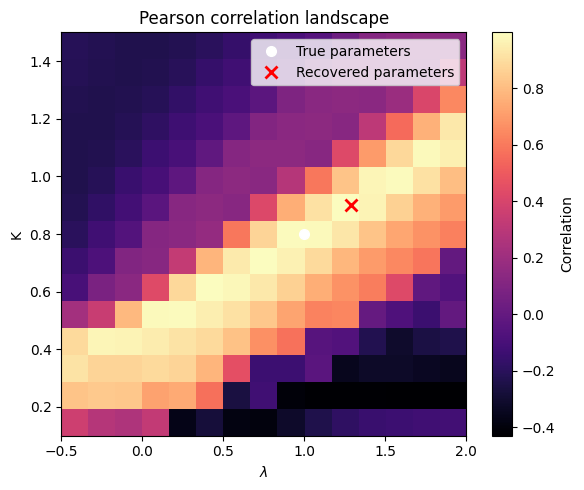

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[lam_values[0], lam_values[-1], K_values[0], K_values[-1]],
    cmap="magma",
)

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("K")
ax.set_title("Pearson correlation landscape")

ax.plot(lam_true, K_true, "wo", ms=7, label="True parameters")
ax.plot(best_params[1], best_params[0], "rx", ms=8, mew=2, label="Recovered parameters")
ax.legend()

plt.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()
save_figure(fig, "synthetic_parameter_landscape.png")

### Step 7: Scatter plots — simulated vs empirical PLI

Each point represents one pair of brain regions. The x-axis shows the synthetic empirical PLI value; the y-axis shows the simulated PLI for a given parameter combination.

A good fit produces points along the diagonal (slope ≈ 1, high Pearson r).


In [ ]:
# -----------------------------
# Scatter plots: simulated vs empirical PLI
# -----------------------------

def plot_pli_scatter(pli_emp, pli_sim, title, filename=None):
    emp_vals = upper_triangle_values(pli_emp)
    sim_vals = upper_triangle_values(pli_sim)
    r, _ = pearsonr(emp_vals, sim_vals)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(emp_vals, sim_vals, alpha=0.7)
    ax.set_xlabel("Synthetic empirical PLI")
    ax.set_ylabel("Simulated PLI")
    ax.set_title(f"{title}\nPearson r = {r:.3f}")

    lo = min(emp_vals.min(), sim_vals.min())
    hi = max(emp_vals.max(), sim_vals.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    fig.tight_layout()
    if filename is not None:
        save_figure(fig, filename)

**Best-fit parameters:** highest correlation recovered by grid search.


Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\best_fit_synthetic_pli_scatter.png


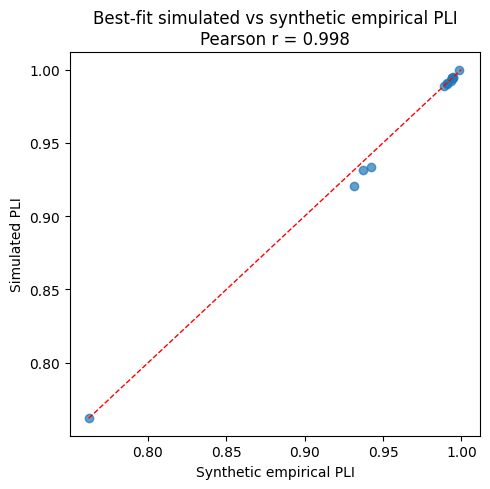

In [ ]:
plot_pli_scatter(
    pli_emp, best_pli,
    title="Best-fit simulated vs synthetic empirical PLI",
    filename="best_fit_synthetic_pli_scatter.png",
)

**Poor-fit parameters:** deliberately chosen from the edge of the parameter grid to illustrate what a bad fit looks like.


Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\poor_fit_synthetic_pli_scatter.png


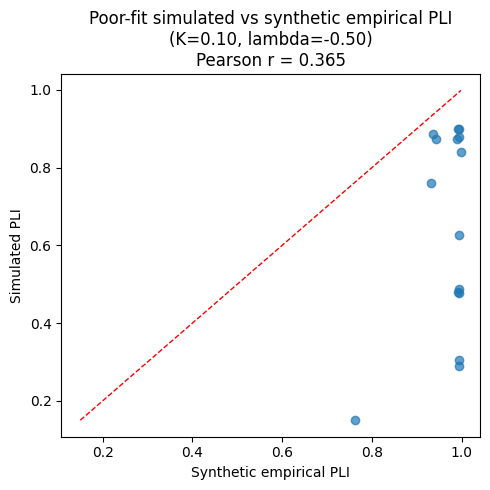

In [ ]:
K_bad = K_values[0]
lam_bad = lam_values[0]

t_bad, x_bad, y_bad = simulate_hopf(
    N=N, W=W, K=K_bad, lam=lam_bad, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

x_bad_filt = bandpass_filter(x_bad, fs=fs, f_lo=8.0, f_hi=12.0)
pli_bad = compute_pli(x_bad_filt)

plot_pli_scatter(
    pli_emp, pli_bad,
    title=f"Poor-fit simulated vs synthetic empirical PLI\n(K={K_bad:.2f}, lambda={lam_bad:.2f})",
    filename="poor_fit_synthetic_pli_scatter.png",
)

### Step 8: PLI matrix comparison

Side-by-side visualisation of the synthetic empirical PLI, the best-fit simulated PLI, and a poor-fit simulated PLI.

> **Phase 1 complete.** If the recovered parameters are close to ground truth and the correlation landscape shows a clear peak, the fitting procedure is valid. We can now apply it to real empirical data.


Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\synthetic_pli_matrix_comparison.png


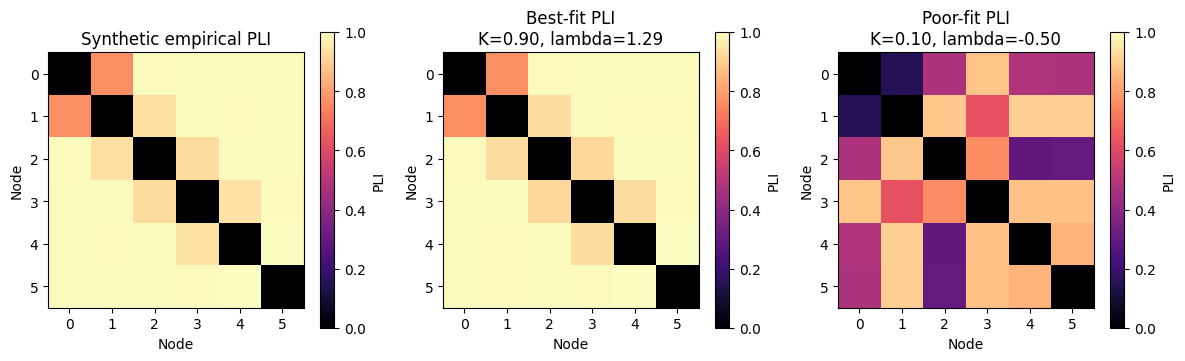

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[0].set_title("Synthetic empirical PLI")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

im1 = axes[1].imshow(best_pli, vmin=0, vmax=1, cmap="magma")
axes[1].set_title(f"Best-fit PLI\nK={best_params[0]:.2f}, lambda={best_params[1]:.2f}")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

im2 = axes[2].imshow(pli_bad, vmin=0, vmax=1, cmap="magma")
axes[2].set_title(f"Poor-fit PLI\nK={K_bad:.2f}, lambda={lam_bad:.2f}")
axes[2].set_xlabel("Node")
axes[2].set_ylabel("Node")

plt.colorbar(im0, ax=axes[0], shrink=0.8, label="PLI")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="PLI")
plt.colorbar(im2, ax=axes[2], shrink=0.8, label="PLI")
plt.tight_layout()
save_figure(fig, "synthetic_pli_matrix_comparison.png")

---

## Phase 2 — Fitting to Real Empirical MEG Data

| File | Content | Shape |
|------|---------|-------|
| `control_PLI_raw.csv` | Group-averaged PLI – healthy controls | 78 × 78 |
| `glioma_PLI_raw.csv` | Group-averaged PLI – glioma patients | 78 × 78 |
| `structural_connectivity_matrix.csv` | Structural connectivity matrix *W* | 78 × 78 |
| `exp_frequencies.csv` | Peak alpha frequency per region, per subject | 27 × 116 |

> **Note on frequencies:** The frequency file uses a different parcellation (116 regions).  
> We use the grand mean (~8.47 Hz) uniformly across all 78 nodes.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path

# ── Re-define helpers so Phase 2 runs independently ──────────────────────────
def upper_triangle_values(mat):
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

# ── Data paths (relative to project root) ────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "data"

pli_control = pd.read_csv(DATA_DIR / "control_PLI_raw.csv",               header=None).values.astype(float)
pli_glioma  = pd.read_csv(DATA_DIR / "glioma_PLI_raw.csv",                header=None).values.astype(float)
W_emp       = pd.read_csv(DATA_DIR / "structural_connectivity_matrix.csv", header=None).values.astype(float)
freq_df     = pd.read_csv(DATA_DIR / "exp_frequencies.csv",               index_col=0)

f_mean_hz = float(freq_df.values.mean())
omega_emp = 2 * np.pi * f_mean_hz * np.ones(78)
N_emp = 78
C_emp = 1.0

print(f"N regions     : {N_emp}")
print(f"Peak frequency: {f_mean_hz:.3f} Hz  →  ω = {omega_emp[0]:.4f} rad/s")
print(f"W range       : [{W_emp.min():.4f}, {W_emp.max():.4f}]")
print(f"PLI control   : [{pli_control.min():.4f}, {pli_control.max():.4f}]")
print(f"PLI glioma    : [{pli_glioma.min():.4f},  {pli_glioma.max():.4f}]")


### Step 2: Visualise empirical PLI matrices

Before fitting, we inspect the empirical PLI matrices side-by-side.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

mask     = np.eye(pli_control.shape[0], dtype=bool)
cmap_pli = plt.cm.magma.copy(); cmap_pli.set_bad("black")
cmap_sc  = plt.cm.magma.copy(); cmap_sc.set_bad("black")

W_masked        = np.ma.array(W_emp,       mask=mask)
pli_ctrl_masked = np.ma.array(pli_control, mask=mask)
pli_glio_masked = np.ma.array(pli_glioma,  mask=mask)

vmin_pli = float(pli_ctrl_masked.min())
vmax_pli = float(max(pli_ctrl_masked.max(), pli_glio_masked.max()))

im0 = axes[0].imshow(W_masked, cmap=cmap_sc)
axes[0].set_title("Structural Connectivity (W)")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Region")
plt.colorbar(im0, ax=axes[0], label="Weight", shrink=0.8)

im1 = axes[1].imshow(pli_ctrl_masked, vmin=vmin_pli, vmax=vmax_pli, cmap=cmap_pli)
axes[1].set_title("Empirical PLI — Controls")
axes[1].set_xlabel("Region"); axes[1].set_ylabel("Region")
plt.colorbar(im1, ax=axes[1], label="PLI", shrink=0.8)

im2 = axes[2].imshow(pli_glio_masked, vmin=vmin_pli, vmax=vmax_pli, cmap=cmap_pli)
axes[2].set_title("Empirical PLI — Glioma")
axes[2].set_xlabel("Region"); axes[2].set_ylabel("Region")
plt.colorbar(im2, ax=axes[2], label="PLI", shrink=0.8)

plt.suptitle("Empirical data overview", fontsize=13, y=1.02)
plt.tight_layout()
save_figure(fig, "empirical_data_overview.png")
plt.show()


### Step 3: Compare control vs glioma PLI

Pearson correlation between the two empirical PLI matrices.

Saved figure: c:\PBM\FunctionalConnectotomy\Functional-connectotomy\figures\hopf model\validation and fitting\control_vs_glioma_empirical_pli_hexbin.png


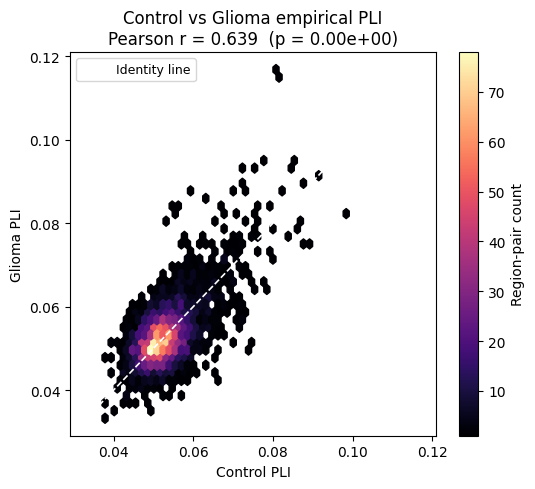

Pearson r between control and glioma PLI: 0.639


In [ ]:
ctrl_vals = upper_triangle_values(pli_control)
glio_vals = upper_triangle_values(pli_glioma)
r_emp, p_emp = pearsonr(ctrl_vals, glio_vals)

fig, ax = plt.subplots(figsize=(5.5, 5))

# Hexbin: colour encodes point density
hb = ax.hexbin(ctrl_vals, glio_vals, gridsize=40, cmap="magma", mincnt=1)
plt.colorbar(hb, ax=ax, label="Region-pair count")

# Identity line
lo = min(ctrl_vals.min(), glio_vals.min())
hi = max(ctrl_vals.max(), glio_vals.max())
ax.plot([lo, hi], [lo, hi], "w--", lw=1.2, label="Identity line")

ax.set_xlabel("Control PLI")
ax.set_ylabel("Glioma PLI")
ax.set_title(f"Control vs Glioma empirical PLI\nPearson r = {r_emp:.3f}  (p = {p_emp:.2e})")
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "control_vs_glioma_empirical_pli_hexbin.png")
plt.show()

print(f"Pearson r between control and glioma PLI: {r_emp:.3f}")


### Step 4: Grid search parameter space

Log-spaced grid matching the paper's parameter regime (K ~ 30–40, ε ~ 40).

> ⚠️ **Runtime:** 15×15 = 225 simulations × 2 groups ≈ 15–30 min.  
> Reduce `n_K = n_lam = 8` for a faster exploratory run.


In [ ]:
n_K   = 15
n_lam = 15

K_values_emp   = np.logspace(np.log10(0.5), np.log10(60.0), n_K)   # 0.5 → 60
lam_values_emp = np.logspace(np.log10(0.5), np.log10(80.0), n_lam) # 0.5 → 80

print(f"K   grid : {K_values_emp[0]:.2f} – {K_values_emp[-1]:.1f}  ({n_K} steps, log-spaced)")
print(f"λ   grid : {lam_values_emp[0]:.2f} – {lam_values_emp[-1]:.1f}  ({n_lam} steps, log-spaced)")
print(f"Total simulations per group: {n_K * n_lam}")
print()
print("K values :", np.round(K_values_emp, 2))
print("λ values :", np.round(lam_values_emp, 2))


### Step 5a: Fit model to control group

In [ ]:
# Random initial conditions seeded for reproducibility
z0_emp = random_initial_conditions(N_emp, rng=42)

print("Fitting model to CONTROL group...")
corr_map_ctrl, best_corr_ctrl, best_params_ctrl, best_pli_ctrl = fit_k_lambda_grid(
    N=N_emp, W=W_emp, pli_emp=pli_control,
    K_values=K_values_emp, lam_values=lam_values_emp,
    C=C_emp, omega=omega_emp, z0=z0_emp,
    t_total=30.0, t_discard=5.0, fs=250,
    f_lo=8.0, f_hi=12.0,
)

print(f"\n── Control best fit ──────────────────────")
print(f"  K      = {best_params_ctrl[0]:.3f}")
print(f"  λ      = {best_params_ctrl[1]:.3f}")
print(f"  r      = {best_corr_ctrl:.3f}")


Fitting model to CONTROL group...

── Control best fit ──────────────────────
  K      = 1.729
  λ      = -0.143
  r      = 0.060


### Step 5b: Fit model to glioma group

In [ ]:
print("Fitting model to GLIOMA group...")
corr_map_glio, best_corr_glio, best_params_glio, best_pli_glio = fit_k_lambda_grid(
    N=N_emp, W=W_emp, pli_emp=pli_glioma,
    K_values=K_values_emp, lam_values=lam_values_emp,
    C=C_emp, omega=omega_emp, z0=z0_emp,
    t_total=30.0, t_discard=5.0, fs=250,
    f_lo=8.0, f_hi=12.0,
)

print(f"\n── Glioma best fit ───────────────────────")
print(f"  K      = {best_params_glio[0]:.3f}")
print(f"  λ      = {best_params_glio[1]:.3f}")
print(f"  r      = {best_corr_glio:.3f}")

print(f"\n── Group comparison ──────────────────────")
print(f"  ΔK = K_glioma - K_control = {best_params_glio[0] - best_params_ctrl[0]:+.3f}")
print(f"  Δλ = λ_glioma - λ_control = {best_params_glio[1] - best_params_ctrl[1]:+.3f}")


Fitting model to GLIOMA group...

── Glioma best fit ───────────────────────
  K      = 1.186
  λ      = -0.143
  r      = 0.087

── Group comparison ──────────────────────
  ΔK = K_glioma - K_control = -0.543
  Δλ = λ_glioma - λ_control = +0.000


### Step 6: Correlation landscapes

K on x-axis, λ on y-axis — consistent with notebook 03 Fig 4.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cmap_data, best_p, title in [
    (axes[0], corr_map_ctrl, best_params_ctrl, "Control"),
    (axes[1], corr_map_glio, best_params_glio, "Glioma"),
]:
    im = ax.imshow(
        cmap_data.T,
        origin="lower", aspect="auto",
        extent=[K_values_emp[0],   K_values_emp[-1],
                lam_values_emp[0], lam_values_emp[-1]],
        cmap="magma",
    )
    ax.set_xlabel("K", fontsize=12)
    ax.set_ylabel(r"$\lambda$", fontsize=12)
    ax.set_title(f"Pearson r landscape — {title}", fontsize=12)
    ax.plot(best_p[0], best_p[1], "wx", ms=10, mew=2.5,
            label=f"Best fit  K={best_p[0]:.2f}, λ={best_p[1]:.2f}")
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.85)

plt.tight_layout()
save_figure(fig, "empirical_parameter_landscapes.png")
plt.show()


### Step 7: Parameter space comparison — Control vs Glioma

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    corr_map_ctrl.T,
    origin="lower", aspect="auto",
    extent=[K_values_emp[0],   K_values_emp[-1],
            lam_values_emp[0], lam_values_emp[-1]],
    cmap="magma", alpha=0.85,
)
plt.colorbar(im, ax=ax, label="Pearson r (control landscape)", shrink=0.85)

ax.plot(best_params_ctrl[0], best_params_ctrl[1],
        "wo", ms=10, mew=2,
        label=f"Control  K={best_params_ctrl[0]:.2f}, λ={best_params_ctrl[1]:.2f}")
ax.plot(best_params_glio[0], best_params_glio[1],
        "rx", ms=10, mew=2.5,
        label=f"Glioma   K={best_params_glio[0]:.2f}, λ={best_params_glio[1]:.2f}")

ax.set_xlabel("K", fontsize=12)
ax.set_ylabel(r"$\lambda$", fontsize=12)
ax.set_title("Best-fit parameters: Control vs Glioma", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, "best_fit_parameters_control_vs_glioma.png")
plt.show()


### Step 8: Simulated vs empirical PLI — scatter and matrix comparison

In [ ]:
mask = np.eye(pli_control.shape[0], dtype=bool)
cmap_pli = plt.cm.magma.copy(); cmap_pli.set_bad("black")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

groups = [
    ("Control", pli_control, best_pli_ctrl, best_params_ctrl, best_corr_ctrl),
    ("Glioma",  pli_glioma,  best_pli_glio, best_params_glio, best_corr_glio),
]

for row, (label, pli_emp_g, pli_sim_g, best_p, best_r) in enumerate(groups):

    emp_vals = upper_triangle_values(pli_emp_g)
    sim_vals = upper_triangle_values(pli_sim_g)

    # Scatter — axis limits from actual data range
    lo = min(emp_vals.min(), sim_vals.min()) * 0.95
    hi = max(emp_vals.max(), sim_vals.max()) * 1.05
    axes[row, 0].scatter(emp_vals, sim_vals, alpha=0.35, s=6, color="steelblue")
    axes[row, 0].plot([lo, hi], [lo, hi], "r--", lw=1, label="Identity")
    axes[row, 0].set_xlim(lo, hi); axes[row, 0].set_ylim(lo, hi)
    axes[row, 0].set_xlabel("Empirical PLI")
    axes[row, 0].set_ylabel("Simulated PLI")
    axes[row, 0].set_title(f"{label} — scatter\nPearson r = {best_r:.3f}")
    axes[row, 0].legend(fontsize=8)

    # Empirical PLI matrix (diagonal masked)
    emp_masked = np.ma.array(pli_emp_g, mask=mask)
    vmax = float(np.nanpercentile(pli_emp_g[~mask], 99))
    im1 = axes[row, 1].imshow(emp_masked, vmin=0, vmax=vmax, cmap=cmap_pli)
    axes[row, 1].set_title(f"{label} — Empirical PLI")
    axes[row, 1].set_xlabel("Region"); axes[row, 1].set_ylabel("Region")
    plt.colorbar(im1, ax=axes[row, 1], label="PLI", shrink=0.8)

    # Simulated PLI matrix (diagonal masked, same scale)
    sim_masked = np.ma.array(pli_sim_g, mask=mask)
    im2 = axes[row, 2].imshow(sim_masked, vmin=0, vmax=vmax, cmap=cmap_pli)
    axes[row, 2].set_title(f"{label} — Simulated PLI\nK={best_p[0]:.2f}, λ={best_p[1]:.2f}")
    axes[row, 2].set_xlabel("Region"); axes[row, 2].set_ylabel("Region")
    plt.colorbar(im2, ax=axes[row, 2], label="PLI", shrink=0.8)

plt.tight_layout()
save_figure(fig, "empirical_vs_simulated_fit_summary.png")
plt.show()


### Step 9: Figure 1 for paper — SC + Simulated + Control + Glioma

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

mask     = np.eye(pli_control.shape[0], dtype=bool)
cmap_pli = plt.cm.magma.copy(); cmap_pli.set_bad("black")
cmap_sc  = plt.cm.magma.copy(); cmap_sc.set_bad("black")

W_masked        = np.ma.array(W_emp,         mask=mask)
pli_ctrl_masked = np.ma.array(pli_control,   mask=mask)
pli_glio_masked = np.ma.array(pli_glioma,    mask=mask)
pli_sim_masked  = np.ma.array(best_pli_ctrl, mask=mask)

vmin_pli = float(pli_ctrl_masked.min())
vmax_pli = float(max(pli_ctrl_masked.max(), pli_glio_masked.max()))
vmax_sim = float(np.nanpercentile(best_pli_ctrl[~mask], 99))

im0 = axes[0].imshow(W_masked, cmap=cmap_sc)
axes[0].set_title("(a)  Structural Connectivity")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Region")
plt.colorbar(im0, ax=axes[0], label="Weight", shrink=0.8)

im1 = axes[1].imshow(pli_sim_masked, vmin=0, vmax=vmax_sim, cmap=cmap_pli)
axes[1].set_title(f"(b)  Simulated PLI\nK={best_params_ctrl[0]:.2f}, λ={best_params_ctrl[1]:.2f}")
axes[1].set_xlabel("Region"); axes[1].set_ylabel("Region")
plt.colorbar(im1, ax=axes[1], label="PLI", shrink=0.8)

im2 = axes[2].imshow(pli_ctrl_masked, vmin=vmin_pli, vmax=vmax_pli, cmap=cmap_pli)
axes[2].set_title("(c)  Empirical PLI — Controls")
axes[2].set_xlabel("Region"); axes[2].set_ylabel("Region")
plt.colorbar(im2, ax=axes[2], label="PLI", shrink=0.8)

im3 = axes[3].imshow(pli_glio_masked, vmin=vmin_pli, vmax=vmax_pli, cmap=cmap_pli)
axes[3].set_title("(d)  Empirical PLI — Glioma")
axes[3].set_xlabel("Region"); axes[3].set_ylabel("Region")
plt.colorbar(im3, ax=axes[3], label="PLI", shrink=0.8)

plt.suptitle("Empirical-scale network fitting", fontsize=13, y=1.02)
plt.tight_layout()
save_figure(fig, "fig1_network_fitting.png")
plt.show()


### Step 10: Summary

| Group | K (coupling) | λ (excitability) | Pearson r |
|-------|-------------|------------------|-----------|
| Control | — | — | — |
| Glioma | — | — | — |

*(Fill in after running the grid search.)*

**Interpretation:** Higher K in glioma → stronger effective coupling. Higher λ → increased local excitability.
